# LFP

In [ ]:
import os
from pathlib import Path
import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import numpy as np
import scipy.signal as signal
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# 1. Configuration & Paths
# ==========================================
si.set_global_job_kwargs(chunk_duration="60s")

# Define the root folder containing all your session subfolders
base_data_folder = r"C:\Mis cosas\Trabajo\EHP\Empírico\Exploración\Data"

# Define where you want the plots and the final dataset to be saved
output_folder = r"C:\Mis cosas\Trabajo\EHP\Empírico\Exploración\Results"
Path(output_folder).mkdir(parents=True, exist_ok=True)

# List to hold the extracted metrics for our dataset
dataset_rows = []

# Find ALL .rhs files in the base directory and its subdirectories
rhs_files = list(Path(base_data_folder).rglob("*.rhs"))
print(f"Found {len(rhs_files)} recordings to process.")

# ==========================================
# 2. Batch Processing Loop
# ==========================================
for file_path in rhs_files:
    recording_id = file_path.stem  # Gets the filename without the .rhs extension
    print(f"\n--- Processing: {recording_id} ---")
    
    try:
        # --- A. Load and Filter ---
        recording = se.read_intan(file_path, stream_name='RHS2000 amplifier channel')
        recording = spre.unsigned_to_signed(recording)
        recording = spre.astype(recording, 'float32')
        rec_notch = spre.notch_filter(recording, freq=50.0)
        rec_filtered = spre.bandpass_filter(rec_notch, freq_min=0.1, freq_max=100.0, ignore_low_freq_error=True)
        rec_lfp = spre.resample(rec_filtered, resample_rate=1000)

        # --- B. Extract Envelopes ---
        lfp_traces = rec_lfp.get_traces(return_scaled=True)
        time_vector = rec_lfp.get_times()
        num_channels = rec_lfp.get_num_channels()

        analytic_signal = signal.hilbert(lfp_traces, axis=0)
        envelopes = np.abs(analytic_signal)

        # Raster data extraction
        channel_burst_times = []
        for i in range(num_channels):
            env = envelopes[:, i]
            thresh = np.mean(env) + 3 * np.std(env)
            peaks, _ = signal.find_peaks(env, height=thresh, distance=100)
            channel_burst_times.append(time_vector[peaks])

        # --- C. Global Network Burst Detection ---
        global_envelope_raw = np.percentile(envelopes, 90, axis=1)
        global_envelope = ndimage.gaussian_filter1d(global_envelope_raw, sigma=50)
        global_threshold = np.mean(global_envelope) + 2 * np.std(global_envelope)

        global_peaks, properties = signal.find_peaks(
            global_envelope, 
            height=global_threshold, 
            distance=500,                       
            width=50,                           
            prominence=np.std(global_envelope)  
        )

        global_burst_times = time_vector[global_peaks]
        global_amplitudes = properties['peak_heights']

        # --- D. Calculate Variables for Dataset ---
        num_bursts = len(global_peaks)
        
        # 1. Inter-burst latency calculations
        if num_bursts > 1:
            ibls = np.diff(global_burst_times)
            mean_ibl = np.mean(ibls)
            min_ibl = np.min(ibls)
            max_ibl = np.max(ibls)
        else:
            mean_ibl, min_ibl, max_ibl = np.nan, np.nan, np.nan

        # 2. Amplitude calculations (NEW)
        if num_bursts > 0:
            mean_amp = np.mean(global_amplitudes)
            min_amp = np.min(global_amplitudes)
            max_amp = np.max(global_amplitudes)
        else:
            mean_amp, min_amp, max_amp = np.nan, np.nan, np.nan

        # Append all metrics to the dataset
        dataset_rows.append({
            "Recording_ID": recording_id,
            "Total_Bursts": num_bursts,
            "IBL_Mean_s": mean_ibl,
            "IBL_Min_s": min_ibl,
            "IBL_Max_s": max_ibl,
            "Amp_Mean_uV": mean_amp,
            "Amp_Min_uV": min_amp,
            "Amp_Max_uV": max_amp
        })

        # --- E. Plot and Save to JPG ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

        ax1.eventplot(channel_burst_times, color='black', linewidths=0.8, alpha=0.7)
        ax1.set_title(f"Array-Wide Burst Raster ({num_channels} Channels) - {recording_id}")
        ax1.set_ylabel("Channel Index")
        ax1.set_yticks([0, num_channels // 2, num_channels - 1])
        ax1.grid(True, axis='x', alpha=0.3)

        ax2.plot(time_vector, global_envelope, label='Smoothed Network Envelope', color='blue', linewidth=1.5)
        ax2.axhline(global_threshold, color='red', linestyle='--', label='Network Burst Threshold')
        ax2.plot(global_burst_times, global_amplitudes, "x", color='darkorange', markersize=10, markeredgewidth=2)

        ax2.set_title("Synchronous Network Bursts")
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("Amplitude (µV)")
        ax2.legend(loc='upper right')
        ax2.set_xlim(time_vector[0], time_vector[-1])

        plt.tight_layout()
        
        # Save the figure
        plot_filename = Path(output_folder) / f"{recording_id}_burst_analysis.jpg"
        plt.savefig(plot_filename, format='jpg', dpi=150)
        
        # CRITICAL: Close the figure to free up RAM before the next iteration
        plt.close(fig)
        print(f"Saved plot: {plot_filename.name} | Bursts: {num_bursts}")

    except Exception as e:
        print(f"FAILED to process {recording_id}. Error: {e}")

# ==========================================
# 3. Export Final Dataset
# ==========================================
print("\nBatch processing complete. Compiling dataset...")
df_results = pd.DataFrame(dataset_rows)

csv_path = Path(output_folder) / "Network_Burst_Dataset.csv"
df_results.to_csv(csv_path, index=False)

print(f"Dataset successfully saved to: {csv_path}")
print(df_results.head()) # Preview the first few rows in the console

Found 5 recordings to process.

--- Processing: Placa 45473 010726 050826_260805_145754 ---


C:\Users\rcver\anaconda3\Lib\site-packages\spikeinterface\preprocessing\filter.py:122: UserWarning: The margin size (1500000 samples) is more than 20% of the global chunk size 1800000 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(
C:\Users\rcver\AppData\Local\Temp\ipykernel_38068\1822558832.py:48: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  lfp_traces = rec_lfp.get_traces(return_scaled=True)


Saved plot: Placa 45473 010726 050826_260805_145754_burst_analysis.jpg | Bursts: 2

--- Processing: Placa 45473 010726 050826_260805_145854 ---


C:\Users\rcver\anaconda3\Lib\site-packages\spikeinterface\preprocessing\filter.py:122: UserWarning: The margin size (1500000 samples) is more than 20% of the global chunk size 1800000 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(
C:\Users\rcver\AppData\Local\Temp\ipykernel_38068\1822558832.py:48: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  lfp_traces = rec_lfp.get_traces(return_scaled=True)


Saved plot: Placa 45473 010726 050826_260805_145854_burst_analysis.jpg | Bursts: 8

--- Processing: Registro PLaca 010726 30um_260722_131905 ---


...

Saved plot: Registro PLaca 010726 30um_260722_131905_burst_analysis.jpg | Bursts: 6

--- Processing: Registro PLaca 010726 30um_260722_132323 ---


C:\Users\rcver\anaconda3\Lib\site-packages\spikeinterface\preprocessing\filter.py:122: UserWarning: The margin size (1500000 samples) is more than 20% of the global chunk size 1800000 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(
C:\Users\rcver\AppData\Local\Temp\ipykernel_38068\1822558832.py:48: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  lfp_traces = rec_lfp.get_traces(return_scaled=True)


Saved plot: Registro PLaca 010726 30um_260722_132323_burst_analysis.jpg | Bursts: 7

--- Processing: Registro PLaca 010726 30um_260722_133318 ---


C:\Users\rcver\anaconda3\Lib\site-packages\spikeinterface\preprocessing\filter.py:122: UserWarning: The margin size (1500000 samples) is more than 20% of the global chunk size 1800000 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(
C:\Users\rcver\AppData\Local\Temp\ipykernel_38068\1822558832.py:48: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  lfp_traces = rec_lfp.get_traces(return_scaled=True)


Saved plot: Registro PLaca 010726 30um_260722_133318_burst_analysis.jpg | Bursts: 5

Batch processing complete. Compiling dataset...
Dataset successfully saved to: C:\Mis cosas\Trabajo\EHP\Empírico\Exploración\Results\Network_Burst_Dataset.csv
                               Recording_ID  Total_Bursts  IBL_Mean_s  \
0   Placa 45473 010726 050826_260805_145754             2   35.898000   
1   Placa 45473 010726 050826_260805_145854             8    7.425714   
2  Registro PLaca 010726 30um_260722_131905             6    5.615800   
3  Registro PLaca 010726 30um_260722_132323             7    7.798667   
4  Registro PLaca 010726 30um_260722_133318             5    2.059500   

   IBL_Min_s  IBL_Max_s  Amp_Mean_uV  Amp_Min_uV  Amp_Max_uV  
0     35.898     35.898    52.548496   43.773224   61.323769  
1      0.563     27.382    27.034539   23.683903   31.594070  
2      3.061      8.133    16.689813   14.517270   18.807457  
3      3.956     17.520    17.169919   15.872477   18.056297  
4 

# Sorting

In [28]:
#doi: 10.3389/fncom.2021.657151
import os
from pathlib import Path
import numpy as np
import pandas as pd
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from sklearn.decomposition import PCA
import hdbscan
import warnings

# Suppress minor warnings for cleaner batch output
warnings.filterwarnings("ignore")

# ==========================================
# 0. Batch Configuration & Paths
# ==========================================
# Define the root folder containing all your session subfolders
base_data_folder = r"C:\Mis cosas\Trabajo\EHP\Empírico\Exploración\Data"

# Define where you want the independent CSV files to be saved
output_folder = r"C:\Mis cosas\Trabajo\EHP\Empírico\Exploración\Results_Sorted_Data"
Path(output_folder).mkdir(parents=True, exist_ok=True)

# Find ALL .rhs files in the base directory and its subdirectories
rhs_files = list(Path(base_data_folder).rglob("*.rhs"))
print(f"Found {len(rhs_files)} recordings to process.")

# Reusable PCA instance[cite: 1]
pca = PCA(n_components=2) 
window_size_ms = 3.0
fs = 14000
window_samples = int((window_size_ms / 1000.0) * fs)
half_window = window_samples // 2

# ==========================================
# Batch Processing Loop
# ==========================================
for file_path in rhs_files:
    recording_id = file_path.stem
    print(f"\n--- Processing: {recording_id} ---")
    
    try:
        # ---------------------------------------------------------
        # 1. Pre-processing
        # ---------------------------------------------------------
        recording = se.read_intan(file_path, stream_name='RHS2000 amplifier channel')
        recording = spre.unsigned_to_signed(recording)
        recording = spre.astype(recording, 'float32')

        # Bandpass filter: 300 to 3000 Hz
        rec_filtered = spre.bandpass_filter(recording, freq_min=300.0, freq_max=3000.0)

        # Downsample to 14 kHz
        rec_sampled = spre.resample(rec_filtered, resample_rate=fs)

        traces = rec_sampled.get_traces(return_scaled=True)
        num_channels = rec_sampled.get_num_channels()

        # ---------------------------------------------------------
        # 2. Threshold Detection
        # ---------------------------------------------------------
        k_multiplier = 4
        noise_mad = np.median(np.abs(traces), axis=0) / 0.6745
        thresholds = k_multiplier * noise_mad

        all_snippets = []
        snippet_channels = []
        snippet_times = []

        for ch in range(num_channels):
            channel_data = traces[:, ch]
            spike_indices = np.where(channel_data < -thresholds[ch])[0]
            
            valid_indices = []
            last_idx = -window_samples
            for idx in spike_indices:
                if idx - last_idx > window_samples:
                    search_start = max(0, idx - half_window)
                    search_end = min(len(channel_data), idx + half_window)
                    local_min_idx = search_start + np.argmin(channel_data[search_start:search_end])
                    
                    if local_min_idx - half_window >= 0 and local_min_idx + half_window < len(channel_data):
                        valid_indices.append(local_min_idx)
                        last_idx = local_min_idx

            for v_idx in valid_indices:
                all_snippets.append(channel_data[v_idx - half_window : v_idx + half_window])
                snippet_channels.append(ch)
                snippet_times.append(v_idx)

        all_snippets = np.array(all_snippets)
        snippet_channels = np.array(snippet_channels)
        snippet_times = np.array(snippet_times)
        
        if len(all_snippets) == 0:
            print(f"Skipping {recording_id}: No spikes detected.")
            continue

        # ---------------------------------------------------------
        # 3. Divide-and-Conquer (Pre-clustering)
        # ---------------------------------------------------------
        unique_snippets = []
        unique_channels = []
        unique_times = []

        sort_order = np.argsort(snippet_times)
        sorted_times = snippet_times[sort_order]
        sorted_snippets = all_snippets[sort_order]
        sorted_channels = snippet_channels[sort_order]

        skip_indices = set()
        for i in range(len(sorted_times)):
            if i in skip_indices:
                continue
                
            simultaneous = [i]
            for j in range(i + 1, len(sorted_times)):
                if sorted_times[j] - sorted_times[i] <= 5:
                    simultaneous.append(j)
                else:
                    break
                    
            if len(simultaneous) > 1:
                amps = [np.max(np.abs(sorted_snippets[idx])) for idx in simultaneous]
                best_idx = simultaneous[np.argmax(amps)]
                unique_snippets.append(sorted_snippets[best_idx])
                unique_channels.append(sorted_channels[best_idx])
                unique_times.append(sorted_times[best_idx])
                skip_indices.update(simultaneous)
            else:
                unique_snippets.append(sorted_snippets[i])
                unique_channels.append(sorted_channels[i])
                unique_times.append(sorted_times[i])

        unique_snippets = np.array(unique_snippets)
        unique_channels = np.array(unique_channels)
        
        # Convert to numpy array to allow boolean masking later
        unique_times_arr = np.array(unique_times)

        # ---------------------------------------------------------
        # 4 & 5. PCA Feature Extraction and HDBSCAN Clustering
        # ---------------------------------------------------------
        cluster_labels_all = np.zeros(len(unique_snippets)) - 1
        templates = {}

        for ch in range(num_channels):
            ch_mask = unique_channels == ch
            ch_snippets = unique_snippets[ch_mask]
            
            if len(ch_snippets) > 10: 
                pca_features = pca.fit_transform(ch_snippets)
                clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
                labels = clusterer.fit_predict(pca_features)
                
                valid_labels = labels >= 0
                global_labels = np.where(valid_labels, labels + (ch * 100), -1)
                cluster_labels_all[ch_mask] = global_labels
                
                unique_local_labels = np.unique(labels[labels >= 0])
                for label in unique_local_labels:
                    cluster_snippets = ch_snippets[labels == label]
                    templates[label + (ch * 100)] = {
                        'waveform': np.mean(cluster_snippets, axis=0),
                        'channel': ch
                    }

        # ---------------------------------------------------------
        # 6. Template Merging
        # ---------------------------------------------------------
        template_ids = list(templates.keys())
        merged_templates = []
        skip_merge = set()

        for i, id1 in enumerate(template_ids):
            if id1 in skip_merge:
                continue
                
            current_merge_group = [id1]
            t1 = templates[id1]
            
            for j in range(i + 1, len(template_ids)):
                id2 = template_ids[j]
                if id2 in skip_merge:
                    continue
                    
                t2 = templates[id2]
                
                if abs(t1['channel'] - t2['channel']) <= 1: 
                    correlation = np.corrcoef(t1['waveform'], t2['waveform'])[0, 1]
                    if correlation > 0.95: 
                        current_merge_group.append(id2)
                        skip_merge.add(id2)
                        
            avg_waveform = np.mean([templates[tid]['waveform'] for tid in current_merge_group], axis=0)
            merged_templates.append({
                'original_ids': current_merge_group,
                'waveform': avg_waveform,
                'primary_channel': t1['channel']
            })

        print(f"Extraction complete. Found {len(merged_templates)} unique units.")
        
        # ---------------------------------------------------------
        # 7. Extract Data and Save to CSV
        # ---------------------------------------------------------
        recording_spike_data = []
        
        # Map original cluster labels to the new merged unit IDs
        for unit_id, template_data in enumerate(merged_templates):
            orig_ids = template_data['original_ids']
            
            # Create a boolean mask to find all spikes belonging to these original IDs
            mask = np.isin(cluster_labels_all, orig_ids)
            
            # Extract the spike times and convert them from sample indices to seconds
            times_in_seconds = unique_times_arr[mask] / fs
            
            # Format each spike event for the DataFrame
            for spike_time in times_in_seconds:
                recording_spike_data.append({
                    "Unit_ID": unit_id,
                    "Primary_Channel": template_data['primary_channel'],
                    "Spike_Time_s": spike_time
                })
        
        # Save to file if data exists
        if len(recording_spike_data) > 0:
            df_spikes = pd.DataFrame(recording_spike_data)
            
            # Sort chronologically before saving
            df_spikes = df_spikes.sort_values(by="Spike_Time_s").reset_index(drop=True)
            
            csv_path = Path(output_folder) / f"{recording_id}_sorted_spikes.csv"
            df_spikes.to_csv(csv_path, index=False)
            print(f"Saved {len(df_spikes)} spike events to: {csv_path.name}")
        else:
            print(f"No sorted spikes passed final extraction for {recording_id}.")

    except Exception as e:
        print(f"FAILED to process {recording_id}. Error: {e}")

print("\nBatch sorting and extraction complete.")

Found 5 recordings to process.

--- Processing: Placa 45473 010726 050826_260805_145754 ---
Extraction complete. Found 21 unique units.
Saved 1092 spike events to: Placa 45473 010726 050826_260805_145754_sorted_spikes.csv

--- Processing: Placa 45473 010726 050826_260805_145854 ---
Extraction complete. Found 28 unique units.
Saved 1943 spike events to: Placa 45473 010726 050826_260805_145854_sorted_spikes.csv

--- Processing: Registro PLaca 010726 30um_260722_131905 ---
Extraction complete. Found 45 unique units.
Saved 2755 spike events to: Registro PLaca 010726 30um_260722_131905_sorted_spikes.csv

--- Processing: Registro PLaca 010726 30um_260722_132323 ---
Extraction complete. Found 41 unique units.
Saved 3886 spike events to: Registro PLaca 010726 30um_260722_132323_sorted_spikes.csv

--- Processing: Registro PLaca 010726 30um_260722_133318 ---
Extraction complete. Found 20 unique units.
Saved 729 spike events to: Registro PLaca 010726 30um_260722_133318_sorted_spikes.csv

Batch so

# Ploting

In [24]:
import os
from pathlib import Path
import numpy as np
import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from sklearn.decomposition import PCA
import hdbscan
import matplotlib.pyplot as plt

# ==========================================
# 1. Configuration & Paths
# ==========================================
si.set_global_job_kwargs(chunk_duration="60s")

# Define the root folder containing all your session subfolders
base_data_folder = r"C:\Mis cosas\Trabajo\EHP\Empírico\Exploración\Data"

# Define where you want the plots to be saved
output_folder = r"C:\Mis cosas\Trabajo\EHP\Empírico\Exploración\Results"
Path(output_folder).mkdir(parents=True, exist_ok=True)

# Find ALL .rhs files in the base directory and its subdirectories
rhs_files = list(Path(base_data_folder).rglob("*.rhs"))
print(f"Found {len(rhs_files)} recordings to process.")

# Reusable PCA instance
pca = PCA(n_components=2)
window_size_ms = 3.0
fs = 14000
window_samples = int((window_size_ms / 1000.0) * fs)
half_window = window_samples // 2

# ==========================================
# 2. Batch Processing Loop
# ==========================================
for file_path in rhs_files:
    recording_id = file_path.stem
    print(f"\n--- Processing: {recording_id} ---")
    
    try:
        # --- A. Pre-processing ---
        recording = se.read_intan(file_path, stream_name='RHS2000 amplifier channel')
        recording = spre.unsigned_to_signed(recording)
        recording = spre.astype(recording, 'float32')
        rec_filtered = spre.bandpass_filter(recording, freq_min=300.0, freq_max=3000.0)
        rec_sampled = spre.resample(rec_filtered, resample_rate=fs)

        traces = rec_sampled.get_traces(return_scaled=True)
        num_channels = rec_sampled.get_num_channels()

        # --- B. Threshold Detection ---
        k_multiplier = 4
        noise_mad = np.median(np.abs(traces), axis=0) / 0.6745
        thresholds = k_multiplier * noise_mad

        all_snippets = []
        snippet_channels = []
        snippet_times = []

        for ch in range(num_channels):
            channel_data = traces[:, ch]
            spike_indices = np.where(channel_data < -thresholds[ch])[0]
            
            valid_indices = []
            last_idx = -window_samples
            for idx in spike_indices:
                if idx - last_idx > window_samples:
                    search_start = max(0, idx - half_window)
                    search_end = min(len(channel_data), idx + half_window)
                    local_min_idx = search_start + np.argmin(channel_data[search_start:search_end])
                    
                    if local_min_idx - half_window >= 0 and local_min_idx + half_window < len(channel_data):
                        valid_indices.append(local_min_idx)
                        last_idx = local_min_idx

            for v_idx in valid_indices:
                all_snippets.append(channel_data[v_idx - half_window : v_idx + half_window])
                snippet_channels.append(ch)
                snippet_times.append(v_idx)

        all_snippets = np.array(all_snippets)
        snippet_channels = np.array(snippet_channels)
        snippet_times = np.array(snippet_times)

        # Skip if no spikes were found
        if len(all_snippets) == 0:
            print(f"Skipping {recording_id}: No spikes detected.")
            continue

        # --- C. Divide-and-Conquer ---
        unique_snippets = []
        unique_channels = []
        unique_times = []

        sort_order = np.argsort(snippet_times)
        sorted_times = snippet_times[sort_order]
        sorted_snippets = all_snippets[sort_order]
        sorted_channels = snippet_channels[sort_order]

        skip_indices = set()
        for i in range(len(sorted_times)):
            if i in skip_indices:
                continue
                
            simultaneous = [i]
            for j in range(i + 1, len(sorted_times)):
                if sorted_times[j] - sorted_times[i] <= 5:
                    simultaneous.append(j)
                else:
                    break
                    
            if len(simultaneous) > 1:
                amps = [np.max(np.abs(sorted_snippets[idx])) for idx in simultaneous]
                best_idx = simultaneous[np.argmax(amps)]
                unique_snippets.append(sorted_snippets[best_idx])
                unique_channels.append(sorted_channels[best_idx])
                unique_times.append(sorted_times[best_idx])
                skip_indices.update(simultaneous)
            else:
                unique_snippets.append(sorted_snippets[i])
                unique_channels.append(sorted_channels[i])
                unique_times.append(sorted_times[i])

        unique_snippets = np.array(unique_snippets)
        unique_channels = np.array(unique_channels)
        unique_times_arr = np.array(unique_times)

        # --- D. PCA & HDBSCAN ---
        cluster_labels_all = np.zeros(len(unique_snippets)) - 1
        templates = {}

        for ch in range(num_channels):
            ch_mask = unique_channels == ch
            ch_snippets = unique_snippets[ch_mask]
            
            if len(ch_snippets) > 10:
                pca_features = pca.fit_transform(ch_snippets)
                clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
                labels = clusterer.fit_predict(pca_features)
                
                valid_labels = labels >= 0
                global_labels = np.where(valid_labels, labels + (ch * 100), -1)
                cluster_labels_all[ch_mask] = global_labels
                
                unique_local_labels = np.unique(labels[labels >= 0])
                for label in unique_local_labels:
                    cluster_snippets = ch_snippets[labels == label]
                    templates[label + (ch * 100)] = {
                        'waveform': np.mean(cluster_snippets, axis=0),
                        'channel': ch
                    }

        # --- E. Template Merging ---
        template_ids = list(templates.keys())
        merged_templates = []
        skip_merge = set()

        for i, id1 in enumerate(template_ids):
            if id1 in skip_merge:
                continue
                
            current_merge_group = [id1]
            t1 = templates[id1]
            
            for j in range(i + 1, len(template_ids)):
                id2 = template_ids[j]
                if id2 in skip_merge:
                    continue
                    
                t2 = templates[id2]
                
                if abs(t1['channel'] - t2['channel']) <= 1: 
                    correlation = np.corrcoef(t1['waveform'], t2['waveform'])[0, 1]
                    if correlation > 0.95: 
                        current_merge_group.append(id2)
                        skip_merge.add(id2)
                        
            avg_waveform = np.mean([templates[tid]['waveform'] for tid in current_merge_group], axis=0)
            merged_templates.append({
                'original_ids': current_merge_group,
                'waveform': avg_waveform,
                'primary_channel': t1['channel']
            })

        print(f"Extracted {len(merged_templates)} units.")
        
        if len(merged_templates) == 0:
            print(f"Skipping plot for {recording_id}: No valid units found after clustering.")
            continue

        # --- F. Map and Plot Raster ---
        unit_spike_times = []
        unit_labels = []
        colors = plt.colormaps.get_cmap('tab20')

        for unit_id, template_data in enumerate(merged_templates):
            orig_ids = template_data['original_ids']
            mask = np.isin(cluster_labels_all, orig_ids)
            times_in_seconds = unique_times_arr[mask] / fs
            
            if len(times_in_seconds) > 0:
                unit_spike_times.append(times_in_seconds)
                unit_labels.append(f"Unit {unit_id}\n(Ch {template_data['primary_channel']})")

        if len(unit_spike_times) > 0:
            fig, ax = plt.subplots(figsize=(14, 8))

            ax.eventplot(
                unit_spike_times, 
                colors=[colors(i % 20) for i in range(len(unit_spike_times))], 
                linewidths=1.0, 
                alpha=0.8
            )

            ax.set_yticks(range(len(unit_labels)))
            ax.set_yticklabels(unit_labels, fontsize=9)
            ax.set_xlabel("Time (s)", fontsize=12)
            ax.set_ylabel("Sorted Units", fontsize=12)
            ax.set_title(f"Sorted Units Raster Plot - {recording_id} ({len(unit_labels)} Units)", fontsize=14)
            ax.grid(True, axis='x', linestyle='--', alpha=0.5)

            if len(unique_times_arr) > 0:
                ax.set_xlim(0, np.max(unique_times_arr) / fs)

            plt.tight_layout()
            
            # Save the figure
            plot_filename = Path(output_folder) / f"{recording_id}_sorted_raster.jpg"
            plt.savefig(plot_filename, format='jpg', dpi=150)
            plt.close(fig)
            print(f"Saved raster plot: {plot_filename.name}")
        else:
            print(f"No valid spike times to plot for {recording_id}.")

    except Exception as e:
        print(f"FAILED to process {recording_id}. Error: {e}")

print("\nBatch raster generation complete.")

Found 5 recordings to process.

--- Processing: Placa 45473 010726 050826_260805_145754 ---


C:\Users\rcver\AppData\Local\Temp\ipykernel_38068\1351525148.py:49: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  traces = rec_sampled.get_traces(return_scaled=True)


Extracted 21 units.
Saved raster plot: Placa 45473 010726 050826_260805_145754_sorted_raster.jpg

--- Processing: Placa 45473 010726 050826_260805_145854 ---


C:\Users\rcver\AppData\Local\Temp\ipykernel_38068\1351525148.py:49: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  traces = rec_sampled.get_traces(return_scaled=True)


Extracted 28 units.
Saved raster plot: Placa 45473 010726 050826_260805_145854_sorted_raster.jpg

--- Processing: Registro PLaca 010726 30um_260722_131905 ---


...

Extracted 45 units.
Saved raster plot: Registro PLaca 010726 30um_260722_131905_sorted_raster.jpg

--- Processing: Registro PLaca 010726 30um_260722_132323 ---


C:\Users\rcver\AppData\Local\Temp\ipykernel_38068\1351525148.py:49: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  traces = rec_sampled.get_traces(return_scaled=True)


Extracted 41 units.
Saved raster plot: Registro PLaca 010726 30um_260722_132323_sorted_raster.jpg

--- Processing: Registro PLaca 010726 30um_260722_133318 ---


C:\Users\rcver\AppData\Local\Temp\ipykernel_38068\1351525148.py:49: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  traces = rec_sampled.get_traces(return_scaled=True)


Extracted 20 units.
Saved raster plot: Registro PLaca 010726 30um_260722_133318_sorted_raster.jpg

Batch raster generation complete.


# Network properties

In [39]:
import numpy as np

def calculate_run_time(spikes, dt, t_start, t_end):
    """Calculate the proportion of total time within +/- dt of any spike."""
    if len(spikes) == 0:
        return 0.0
    
    # Calculate time windows [spike - dt, spike + dt]
    windows = np.zeros((len(spikes), 2))
    windows[:, 0] = np.maximum(spikes - dt, t_start)
    windows[:, 1] = np.minimum(spikes + dt, t_end)
    
    # Merge overlapping windows
    merged_windows = []
    current_start, current_end = windows[0]
    
    for i in range(1, len(windows)):
        start, end = windows[i]
        if start <= current_end:
            current_end = max(current_end, end)
        else:
            merged_windows.append((current_start, current_end))
            current_start = start
            current_end = end
    merged_windows.append((current_start, current_end))
    
    # Calculate total time covered by these windows
    total_time = sum([end - start for start, end in merged_windows])
    
    # Return proportion of total recording time
    return total_time / (t_end - t_start)

def calculate_spikes_in_window(spikes_1, spikes_2, dt):
    """Calculate proportion of spikes_1 that fall within +/- dt of any spike_2."""
    if len(spikes_1) == 0 or len(spikes_2) == 0:
        return 0.0
    
    # Fast search to find the closest spike in array 2 for each spike in array 1
    indices = np.searchsorted(spikes_2, spikes_1)
    
    # Check left and right nearest neighbors
    left_valid = (indices > 0) & (np.abs(spikes_1 - spikes_2[np.minimum(indices - 1, len(spikes_2)-1)]) <= dt)
    right_valid = (indices < len(spikes_2)) & (np.abs(spikes_1 - spikes_2[np.minimum(indices, len(spikes_2)-1)]) <= dt)
    
    # Count how many spikes in 1 are within dt of any spike in 2
    matches = np.sum(left_valid | right_valid)
    
    return matches / len(spikes_1)

def compute_sttc(spikes_A, spikes_B, dt, t_start, t_end):
    """Compute the Spike Time Tiling Coefficient (Cutts & Eglen, 2014)."""
    if len(spikes_A) == 0 or len(spikes_B) == 0:
        return 0.0
        
    T_A = calculate_run_time(spikes_A, dt, t_start, t_end)
    T_B = calculate_run_time(spikes_B, dt, t_start, t_end)
    
    P_A = calculate_spikes_in_window(spikes_A, spikes_B, dt)
    P_B = calculate_spikes_in_window(spikes_B, spikes_A, dt)
    
    # Handle mathematical edge cases where denominator might be 0
    if P_A * T_B == 1.0:
        term1 = 0.0
    else:
        term1 = (P_A - T_B) / (1.0 - P_A * T_B)
        
    if P_B * T_A == 1.0:
        term2 = 0.0
    else:
        term2 = (P_B - T_A) / (1.0 - P_B * T_A)
        
    return 0.5 * (term1 + term2)

# Connectivity maps

Found 5 sorted recordings to load.

Analyzing 4 electrodes.
Calculating STTC matrix for Placa 45473 010726 050826_260805_145754...
Calculating STTC matrix for Placa 45473 010726 050826_260805_145854...
Calculating STTC matrix for Registro PLaca 010726 30um_260722_131905...
Calculating STTC matrix for Registro PLaca 010726 30um_260722_132323...
Calculating STTC matrix for Registro PLaca 010726 30um_260722_133318...


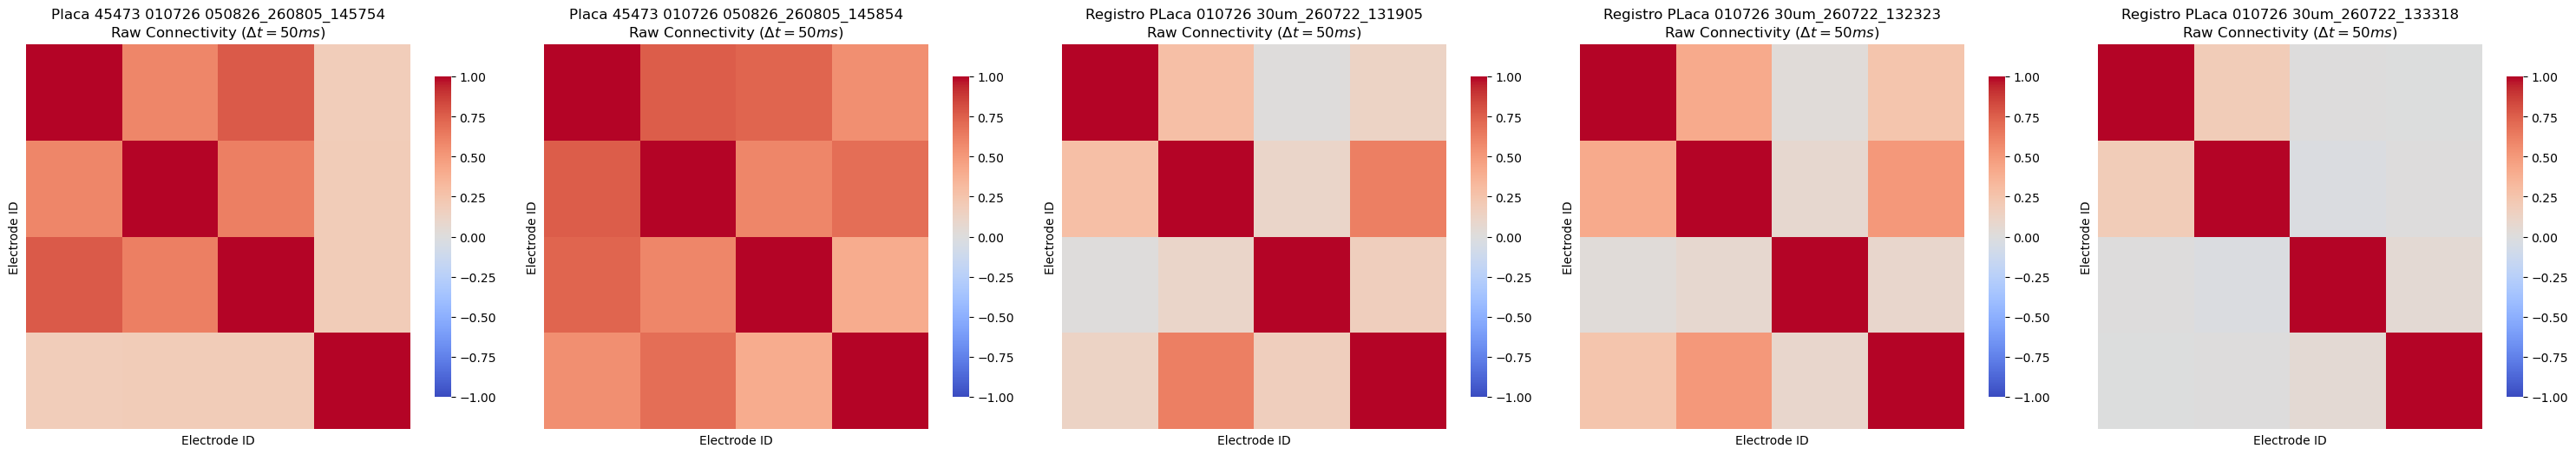


--- Applying 10% Proportional Thresholding ---
Placa 45473 010726 050826_260805_145754: Keeping STTC >= 0.7524
Placa 45473 010726 050826_260805_145854: Keeping STTC >= 0.7585
Registro PLaca 010726 30um_260722_131905: Keeping STTC >= 0.5852
Registro PLaca 010726 30um_260722_132323: Keeping STTC >= 0.4965
Registro PLaca 010726 30um_260722_133318: Keeping STTC >= 0.1765


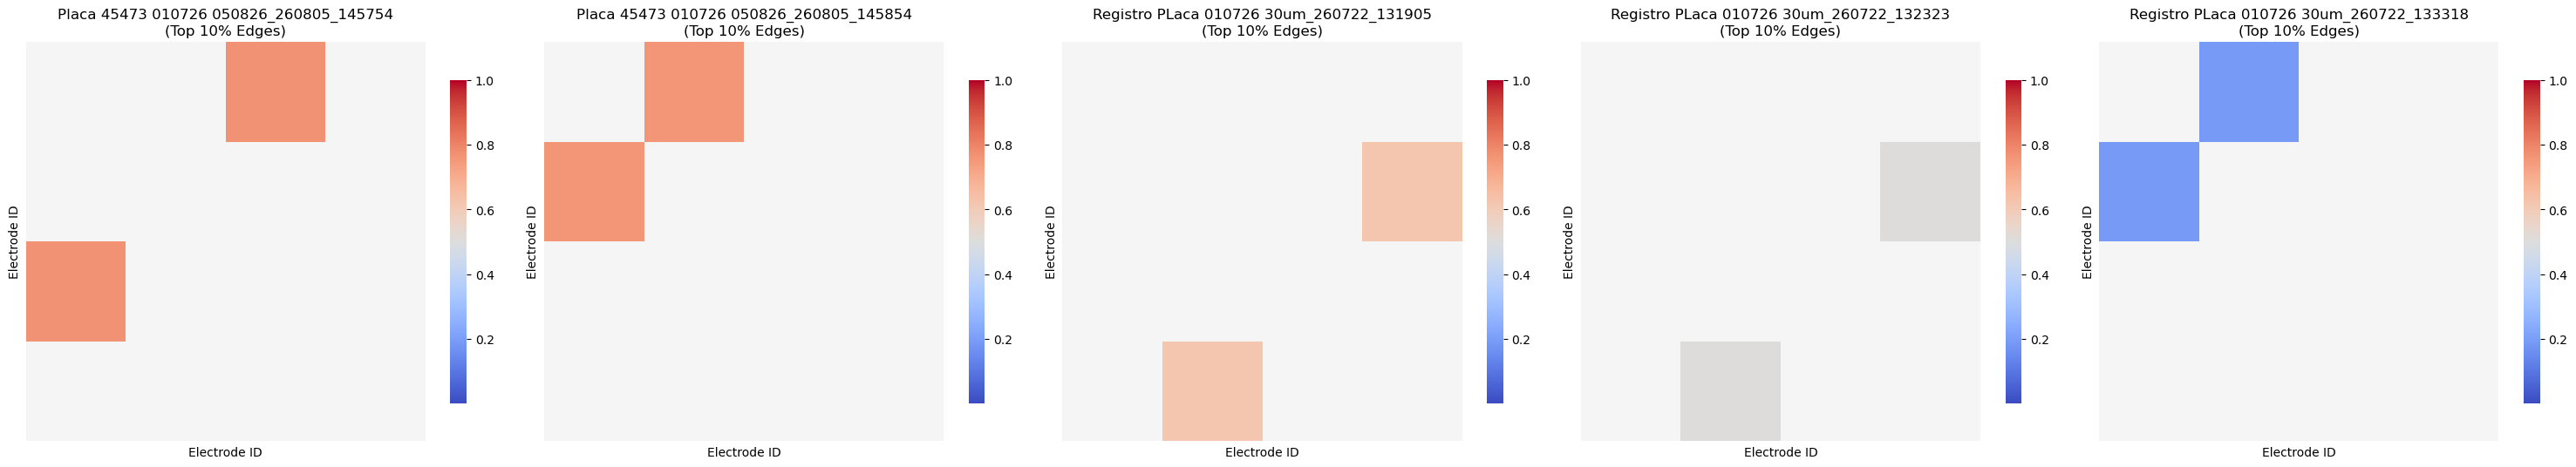

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Helper Function (Ensure you have this defined in your environment) ---
# def compute_sttc(spikes_A, spikes_B, dt, t_start, t_end):
#     ...

# =========================================================
# 1. Load Data (Electrode-Level)
# =========================================================
base_data_folder = r"C:\Mis cosas\Trabajo\EHP\Empírico\Exploración\Results_Sorted_Data"
csv_files = list(Path(base_data_folder).rglob("*_sorted_spikes.csv"))
print(f"Found {len(csv_files)} sorted recordings to load.")

files = {file_path.name.replace("_sorted_spikes.csv", ""): file_path for file_path in csv_files}

dt = 0.05  
datasets = {}
neuron_sets = []

for cond, filepath in files.items():
    try:
        df = pd.read_csv(filepath)
    except Exception as e:
        print(f"Error loading {filepath.name}: {e}")
        continue
    
    # Group by physical electrode
    df['NeuronLabel'] = 'E' + df['Primary_Channel'].astype(str)
    
    labels = df['NeuronLabel'].unique()
    spike_trains = {}
    
    for label in labels:
        spikes = df[df['NeuronLabel'] == label]['Spike_Time_s'].values
        spike_trains[label] = np.sort(np.unique(spikes)) 
    
    datasets[cond] = {
        'spike_trains': spike_trains,
        't_start': df['Spike_Time_s'].min(),
        't_end': df['Spike_Time_s'].max()
    }
    neuron_sets.append(set(labels))

if len(neuron_sets) > 0:
    common_neurons = list(set.intersection(*neuron_sets))
    common_neurons.sort(key=lambda x: int(x[1:])) 
    print(f"\nAnalyzing {len(common_neurons)} electrodes.")
else:
    print("\nNo datasets were successfully loaded.")
    exit()

# =========================================================
# 2. Compute Rate-Corrected STTC Matrices
# =========================================================
sttc_matrices = {}
n_neurons = len(common_neurons)

for cond, data in datasets.items():
    print(f"Calculating STTC matrix for {cond}...")
    matrix = np.zeros((n_neurons, n_neurons))
    
    for i in range(n_neurons):
        for j in range(n_neurons):
            if i == j:
                matrix[i, j] = 1.0 
            else:
                spikes_A = data['spike_trains'][common_neurons[i]]
                spikes_B = data['spike_trains'][common_neurons[j]]
                matrix[i, j] = compute_sttc(spikes_A, spikes_B, dt, data['t_start'], data['t_end'])
                
    sttc_matrices[cond] = pd.DataFrame(matrix, index=common_neurons, columns=common_neurons)

# =========================================================
# 3. Dynamic Plotting (Raw STTC)
# =========================================================
n_conds = len(sttc_matrices)
# Create exactly as many subplots as there are conditions
fig, axes = plt.subplots(1, n_conds, figsize=(6 * n_conds, 5))

# If there is only 1 condition, plt.subplots returns a single axes object, not an array.
if n_conds == 1:
    axes = [axes]

for ax, (cond, matrix) in zip(axes, sttc_matrices.items()):
    sns.heatmap(matrix, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
                xticklabels=False, yticklabels=False, ax=ax, square=True, cbar_kws={"shrink": .8})
    ax.set_title(f'{cond}\nRaw Connectivity ($\Delta t = 50ms$)')
    ax.set_xlabel('Electrode ID')
    ax.set_ylabel('Electrode ID')

plt.tight_layout()
plt.show()

# =========================================================
# 4. Proportional Thresholding & Binarization
# =========================================================
thresholded_matrices = {}
binarized_matrices = {}
target_density = 10 

print(f"\n--- Applying {target_density}% Proportional Thresholding ---")

for cond, matrix in sttc_matrices.items():
    np_mat = matrix.values
    off_diagonal_vals = np_mat[~np.eye(np_mat.shape[0], dtype=bool)]
    
    # Safety Check for small matrices
    if len(off_diagonal_vals) == 0:
        print(f"{cond}: Matrix too small to threshold.")
        continue
    
    percentile_cutoff = 100 - target_density
    threshold = np.percentile(off_diagonal_vals, percentile_cutoff)
    print(f"{cond}: Keeping STTC >= {threshold:.4f}")
    
    thresh_mat = matrix.copy()
    thresh_mat[thresh_mat < threshold] = 0.0
    np.fill_diagonal(thresh_mat.values, 0.0) 
    thresholded_matrices[cond] = thresh_mat
    
    bin_mat = (matrix >= threshold).astype(int)
    np.fill_diagonal(bin_mat.values, 0)
    binarized_matrices[cond] = bin_mat

# =========================================================
# 5. Dynamic Plotting (Thresholded STTC)
# =========================================================
if thresholded_matrices:
    fig, axes = plt.subplots(1, n_conds, figsize=(6 * n_conds, 5))
    if n_conds == 1:
        axes = [axes]

    for ax, (cond, thresh_mat) in zip(axes, thresholded_matrices.items()):
        cmap = sns.color_palette("coolwarm", as_cmap=True)
        cmap.set_under('whitesmoke') 
        
        sns.heatmap(thresh_mat, cmap=cmap, vmin=0.001, vmax=1, 
                    xticklabels=False, yticklabels=False, ax=ax, square=True, cbar_kws={"shrink": .8})
        
        ax.set_title(f'{cond}\n(Top {target_density}% Edges)')
        ax.set_xlabel('Electrode ID')
        ax.set_ylabel('Electrode ID')

    plt.tight_layout()
    plt.show()

# metrics

--- Computing Graph Metrics ---


,Char. Path Length (L),Modularity (Q),Small-worldness (σ),Clustering Coeff (C),Global Efficiency
Condition,,,,,
Placa 45473 010726 050826_260805_145754,1.000000,0.0,1.0,1.0,1.000000
Placa 45473 010726 050826_260805_145854,1.000000,0.0,1.0,1.0,1.000000
Registro PLaca 010726 30um_260722_131905,1.000000,0.0,1.0,1.0,1.000000
Registro PLaca 010726 30um_260722_132323,1.000000,0.0,1.0,1.0,1.000000
Registro PLaca 010726 30um_260722_133318,1.333333,0.0,0.0,0.0,0.833333


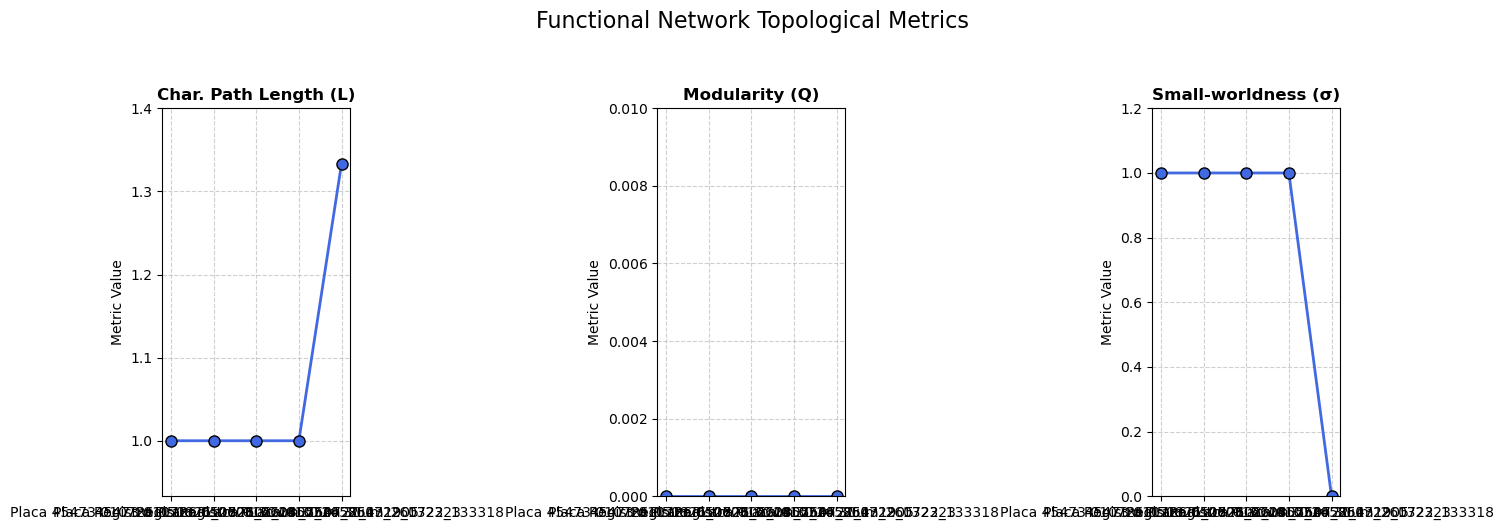

In [42]:
# ---------------------------------------------------------
# 5. Graph-Theoretic Network Diagnostics
# ---------------------------------------------------------
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- Computing Graph Metrics ---")

# =========================================================
# BOOLEAN TOGGLE: MASKED VS UNMASKED
# True = Uses the 10% density binarized matrix (Top 10% strongest connections).
# False = Uses the unmasked matrix (All positive STTC connections > 0).
# =========================================================
use_threshold_mask = False 

graph_metrics = {
    'Condition': [],
    'Char. Path Length (L)': [],
    'Modularity (Q)': [],
    'Small-worldness (σ)': [],
    'Clustering Coeff (C)': [],
    'Global Efficiency': []
}

for cond in sttc_matrices.keys():
    # Apply the selected masking criteria
    if use_threshold_mask:
        working_mat = binarized_matrices[cond].values
    else:
        # Unmasked: Convert all positive STTC correlations into edges
        working_mat = (sttc_matrices[cond].values > 0).astype(int)
        np.fill_diagonal(working_mat, 0)
        
    df_adj = pd.DataFrame(working_mat, index=common_neurons, columns=common_neurons)
    G = nx.from_pandas_adjacency(df_adj)
    
    # Safety check: If the graph has zero edges, metrics will collapse to 0
    if G.number_of_edges() == 0:
        print(f"Warning: The network for '{cond}' has 0 edges. Metrics will default to 0.")
        graph_metrics['Condition'].append(cond)
        graph_metrics['Char. Path Length (L)'].append(0)
        graph_metrics['Modularity (Q)'].append(0)
        graph_metrics['Small-worldness (σ)'].append(0)
        graph_metrics['Clustering Coeff (C)'].append(0)
        graph_metrics['Global Efficiency'].append(0)
        continue
    
    lcc_nodes = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(lcc_nodes).copy()
    
    C = nx.average_clustering(G) 
    
    # Path length requires at least 2 nodes in the LCC to avoid division by zero
    if len(G_lcc) > 1:
        L = nx.average_shortest_path_length(G_lcc)
    else:
        L = 0
        
    E_glob = nx.global_efficiency(G)
    
    # Modularity requires edges to form communities
    communities = nx.community.greedy_modularity_communities(G)
    Q = nx.community.modularity(G, communities) if len(communities) > 0 else 0
    
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    p_edge = (2.0 * n_edges) / (n_nodes * (n_nodes - 1)) if n_nodes > 1 else 0
    
    C_rand_list, L_rand_list = [], []
    
    for i in range(50):
        G_rand = nx.erdos_renyi_graph(n_nodes, p_edge, seed=42 + i)
        C_rand_list.append(nx.average_clustering(G_rand))
        
        if len(G_rand.edges()) > 0: 
            rand_lcc = max(nx.connected_components(G_rand), key=len)
            G_rand_lcc = G_rand.subgraph(rand_lcc)
            if len(G_rand_lcc) > 1:
                L_rand_list.append(nx.average_shortest_path_length(G_rand_lcc))
                
    C_rand = np.mean(C_rand_list) if C_rand_list else 1.0
    L_rand = np.mean(L_rand_list) if L_rand_list else 1.0
    
    sigma = (C / C_rand) / (L / L_rand) if (C_rand > 0 and L_rand > 0) else 0
    
    graph_metrics['Condition'].append(cond)
    graph_metrics['Char. Path Length (L)'].append(L)
    graph_metrics['Modularity (Q)'].append(Q)
    graph_metrics['Small-worldness (σ)'].append(sigma)
    graph_metrics['Clustering Coeff (C)'].append(C)
    graph_metrics['Global Efficiency'].append(E_glob)

# Convert to DataFrame for easy viewing
df_metrics = pd.DataFrame(graph_metrics)
display(df_metrics.set_index('Condition'))

# ---------------------------------------------------------
# Dynamic Plotting
# ---------------------------------------------------------
metrics_to_plot = ['Char. Path Length (L)', 'Modularity (Q)', 'Small-worldness (σ)']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

is_single_condition = len(df_metrics) == 1

for ax, metric in zip(axes, metrics_to_plot):
    if is_single_condition:
        ax.bar(df_metrics['Condition'], df_metrics[metric], color='royalblue', 
               edgecolor='black', linewidth=1.5, width=0.4)
    else:
        ax.plot(df_metrics['Condition'], df_metrics[metric], 
                marker='o', markersize=8, linewidth=2, color='royalblue', 
                markeredgecolor='black', markeredgewidth=1)

    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Metric Value')
    
    if is_single_condition:
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    else:
        ax.grid(True, linestyle='--', alpha=0.6)
    
    y_min, y_max = df_metrics[metric].min(), df_metrics[metric].max()
    y_range = max(y_max - y_min, 0.05) 
    ax.set_ylim(max(0, y_min - y_range*0.2), y_max + y_range*0.2) 

plt.suptitle('Functional Network Topological Metrics', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()